# Day_2  : Building CNNs & Transfer Learning

## Objective

This notebook demonstrates the complete workflow for image classification using
a binary melanoma skin cancer dataset.

The main goal is to compare three approaches:

1. A CNN trained from scratch.
2. A CNN with data augmentation.
3. Transfer learning using a pre-trained MobileNetV2 model.

The models are evaluated based on validation/test performance and training time.

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    RandomFlip,
    RandomRotation,
    RandomZoom
)
from tensorflow.keras.applications import MobileNetV2

In [3]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
train_dir = '/content/drive/MyDrive/Cancer_ Dataset/train'
test_dir = '/content/drive/MyDrive/Cancer_ Dataset/test'



In [5]:
import os

for split, split_dir in [("Train", train_dir), ("Test", test_dir)]:
    print(f"\n{split} Dataset")

    for class_name in ["Malignant", "Benign"]:
        class_dir = os.path.join(split_dir, class_name)
        num_images = len([
            file for file in os.listdir(class_dir)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        print(f"{class_name}: {num_images} images")


Train Dataset
Malignant: 5590 images
Benign: 6289 images

Test Dataset
Malignant: 1000 images
Benign: 1000 images


In [6]:
train_counts = {
    "Malignant": 5590,
    "Benign": 6289
}

test_counts = {
    "Malignant": 1000,
    "Benign": 1000
}

print("Train Distribution:")
for class_name, count in train_counts.items():
    percentage = (count / sum(train_counts.values())) * 100
    print(f"{class_name}: {count} ({percentage:.2f}%)")

print("\nTest Distribution:")
for class_name, count in test_counts.items():
    percentage = (count / sum(test_counts.values())) * 100
    print(f"{class_name}: {count} ({percentage:.2f}%)")

Train Distribution:
Malignant: 5590 (47.06%)
Benign: 6289 (52.94%)

Test Distribution:
Malignant: 1000 (50.00%)
Benign: 1000 (50.00%)


## Visualizing the Dataset

Before applying any preprocessing techniques, we first inspect the original images.

This step helps us understand:
- The visual appearance of each class.
- Differences between Benign and Malignant images.
- The quality and variability of the images.
- Whether there are any obvious issues in the raw dataset.

We will visualize a few samples from both classes.

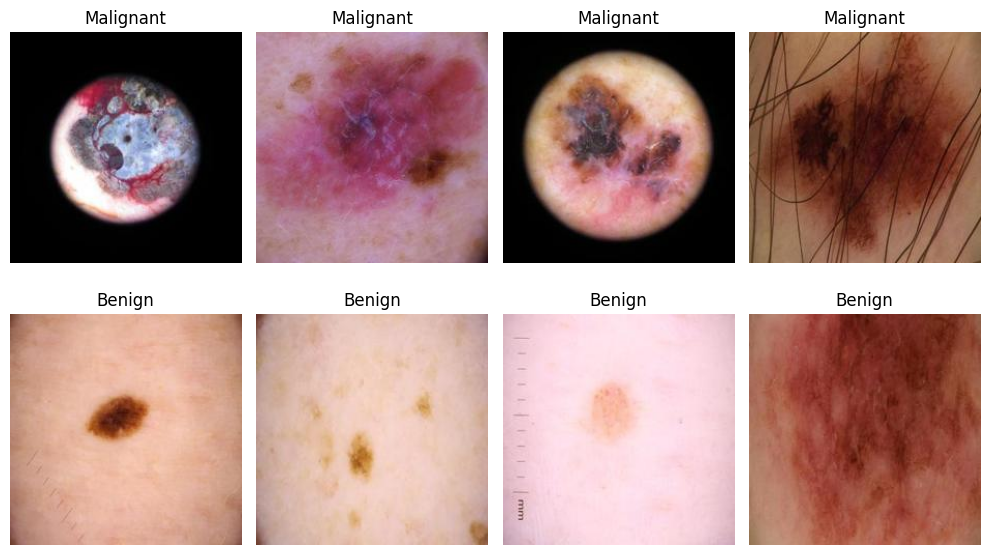

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

classes = ["Malignant", "Benign"]

plt.figure(figsize=(10, 6))

for i, class_name in enumerate(classes):
    class_dir = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for j in range(4):
        image_path = os.path.join(class_dir, image_files[j])
        image = Image.open(image_path)

        plt.subplot(2, 4, i * 4 + j + 1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

### Image Properties

Before preprocessing the images, we inspect their original dimensions, color channels, and image format.

Understanding the original image properties helps us decide how the images should be prepared before training the CNN models.

In [8]:
# Select one image from each class
sample_images = {}

for class_name in classes:
    class_dir = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_dir, image_files[0])
    sample_images[class_name] = Image.open(image_path)

# Display image properties
for class_name, image in sample_images.items():
    print(f"{class_name}:")
    print(f"  Format: {image.format}")
    print(f"  Size: {image.size}")
    print(f"  Mode: {image.mode}")
    print()

Malignant:
  Format: JPEG
  Size: (224, 224)
  Mode: RGB

Benign:
  Format: JPEG
  Size: (224, 224)
  Mode: RGB



### Image Dimension Consistency

We check whether the images in the dataset have consistent dimensions.

Consistent image dimensions are important because CNN models require input images with the same shape.

In [9]:
# Check image dimensions across the dataset

for split, split_dir in [("Train", train_dir), ("Test", test_dir)]:
    sizes = {}

    for class_name in classes:
        class_dir = os.path.join(split_dir, class_name)

        image_files = [
            file for file in os.listdir(class_dir)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        for file in image_files:
            image_path = os.path.join(class_dir, file)

            with Image.open(image_path) as image:
                size = image.size
                sizes[size] = sizes.get(size, 0) + 1

    print(f"\n{split} Dataset:")
    print(f"Number of different image sizes: {len(sizes)}")

    for size, count in sizes.items():
        print(f"{size}: {count} images")


Train Dataset:
Number of different image sizes: 1
(224, 224): 11879 images

Test Dataset:
Number of different image sizes: 1
(224, 224): 2000 images


### Class Distribution Visualization

We visualize the class distribution using a bar chart to clearly compare the number of images in each class.

The training set contains a small difference between the two classes, while the test set is perfectly balanced.

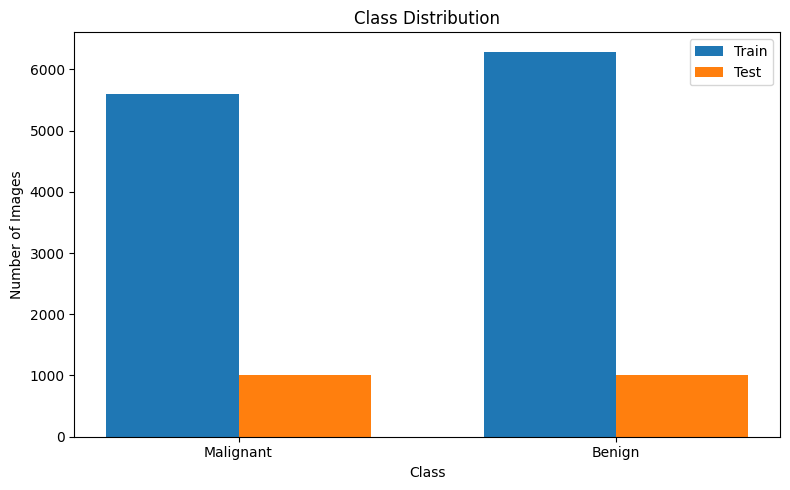

In [10]:
# Class distribution values
train_counts = [5590, 6289]
test_counts = [1000, 1000]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width / 2, train_counts, width, label="Train")
plt.bar(x + width / 2, test_counts, width, label="Test")

plt.xticks(x, classes)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.legend()

plt.tight_layout()
plt.show()

##  Image Preprocessing

Before training the CNN models, the images need to be prepared for the neural network.

The preprocessing steps in this notebook will include:

- Resizing images to a suitable input size.
- Normalizing pixel values.
- Preparing the dataset for efficient training.

Since the original images are already consistent at 224 × 224 pixels and use RGB format,
we do not need to perform additional resizing before loading them.

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
Found 2000 files belonging to 2 classes.


### Pixel Value Normalization

Images are initially represented using pixel values ranging from 0 to 255.

Neural networks generally train more effectively when input values are on a smaller and consistent scale.

Therefore, we normalize the pixel values from the range [0, 255] to [0, 1] by dividing them by 255.

In [12]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

val_ds = val_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_ds = test_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

### Verify Pixel Normalization

We verify that the pixel values have been successfully scaled to the range [0, 1].

In [13]:
for images, labels in train_ds.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)


Minimum pixel value: 0.0
Maximum pixel value: 1.0
Image shape: (32, 224, 224, 3)
Label shape: (32, 1)


##  Building a CNN from Scratch

In this section, we build a Convolutional Neural Network (CNN) from scratch.

The CNN will learn visual features directly from the melanoma images without using
a pre-trained model.

The architecture consists of:

- Convolutional layers for feature extraction.
- ReLU activation for introducing non-linearity.
- MaxPooling layers for reducing spatial dimensions.
- A Flatten layer to convert feature maps into a one-dimensional vector.
- Dense layers for classification.
- A Sigmoid output layer for binary classification.

In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(64, activation="relu"),

    Dense(1, activation="sigmoid")
])

cnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the CNN

Before training the CNN, we need to configure the model using three main components:

- **Optimizer:** Adam is used to update the model weights during training.
- **Loss Function:** Binary Crossentropy is used because this is a binary classification problem.
- **Metric:** Accuracy is used to monitor the percentage of correct predictions.

Since the model has a single Sigmoid output neuron, Binary Crossentropy is appropriate for the two classes: Benign and Malignant.

In [15]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [16]:
import time

start_time = time.time()

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

cnn_training_time = time.time() - start_time

print(f"Training time: {cnn_training_time:.2f} seconds")

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.7367 - loss: 0.5961 - val_accuracy: 0.8160 - val_loss: 0.3946
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8214 - loss: 0.3928 - val_accuracy: 0.8261 - val_loss: 0.3751
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.8418 - loss: 0.3503 - val_accuracy: 0.8362 - val_loss: 0.3538
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.8525 - loss: 0.3319 - val_accuracy: 0.8396 - val_loss: 0.3485
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.8581 - loss: 0.3172 - val_accuracy: 0.8227 - val_loss: 0.3638
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.8764 - loss: 0.2864 - val_accuracy: 0.8446 - val_loss: 0.3382
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8779 - loss: 0.2754 - val_accuracy: 0.8413 - val_loss: 0.3420
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.8879 - loss: 0.2624 - 

In [17]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss: {cnn_test_loss:.4f}")
print(f"Test Accuracy: {cnn_test_accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.8450 - loss: 0.3688
Test Loss: 0.3688
Test Accuracy: 0.8450


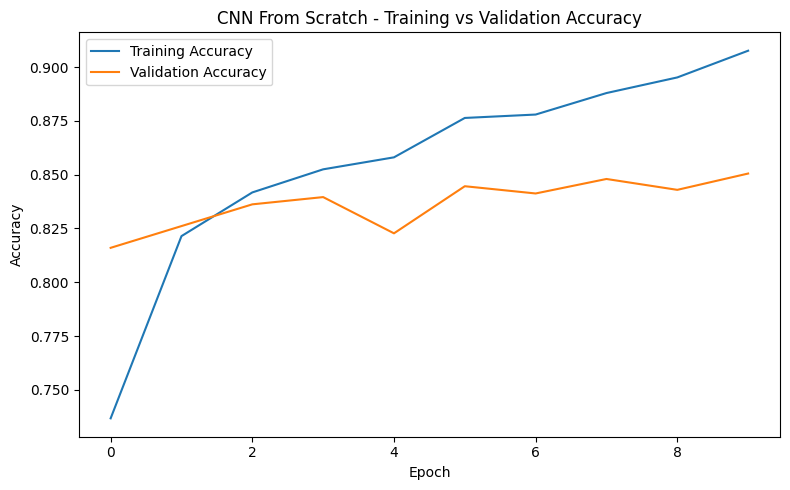

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN From Scratch - Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

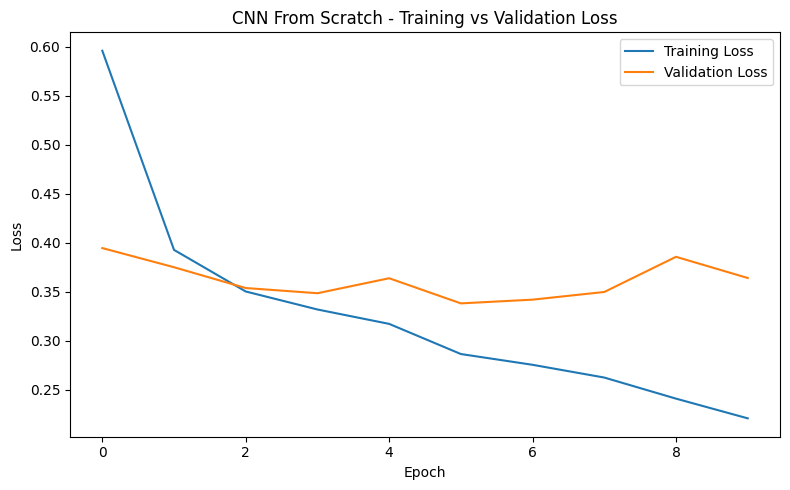

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN From Scratch - Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

##  Data Augmentation

Data augmentation artificially increases the variety of training images by applying
random transformations such as flipping, rotation, and zooming.

These transformations do not create completely new images. Instead, they generate
different versions of existing training images.

The goal is to reduce overfitting and improve the model's ability to generalize
to unseen images.

In this section, we will add data augmentation to the CNN and compare its
performance with the baseline CNN trained from scratch.

In [22]:
data_augmentation = Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

class_names = ["Benign", "Malignant"]

print(class_names)

['Benign', 'Malignant']


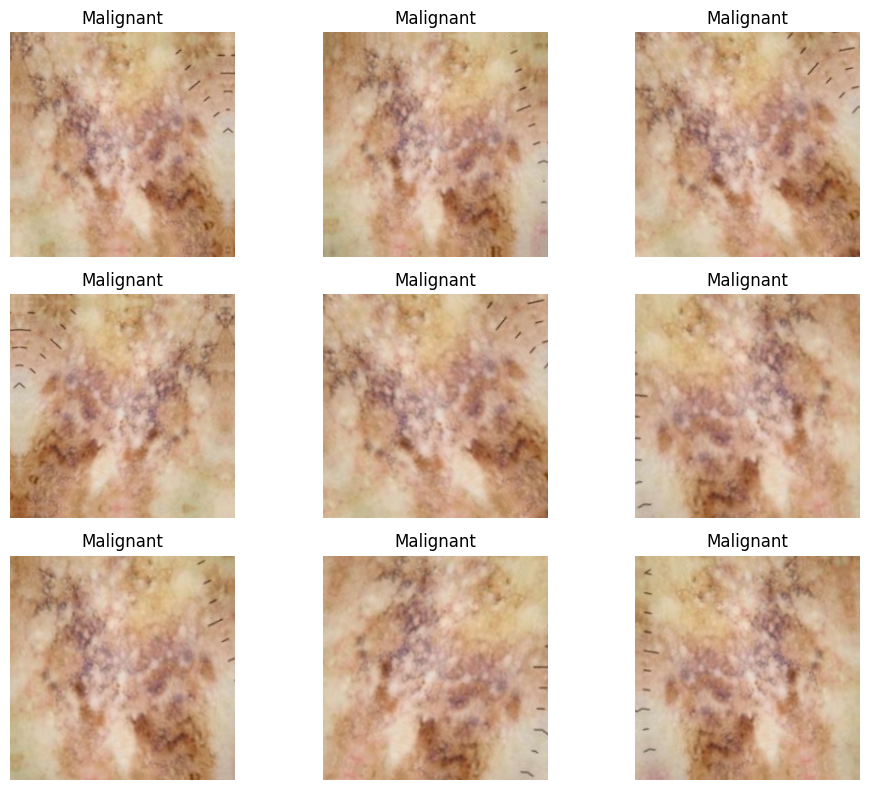

In [23]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    original_image = images[0]
    label = int(labels[0].numpy()[0])

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(original_image, 0),
            training=True
        )[0]

        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy())
        plt.title(class_names[label])
        plt.axis("off")

plt.tight_layout()
plt.show()

### Building a CNN with Data Augmentation

We now build a second CNN that includes data augmentation as part of the
model architecture.

The augmentation layers are applied only during training. This allows the
model to learn from more varied versions of the training images and helps
reduce overfitting.

The convolutional architecture remains the same as the baseline model so
that we can make a fair comparison between the two approaches.

In [25]:
cnn_aug_model = Sequential([
    data_augmentation,

    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(64, activation="relu"),

    Dense(1, activation="sigmoid")
])

cnn_aug_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (1, 186624)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 64)                │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
cnn_aug_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
start_time = time.time()

cnn_aug_history = cnn_aug_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

cnn_aug_training_time = time.time() - start_time

print(f"Training time: {cnn_aug_training_time:.2f} seconds")

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.7670 - loss: 0.5432 - val_accuracy: 0.8282 - val_loss: 0.3959
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.8248 - loss: 0.3939 - val_accuracy: 0.8354 - val_loss: 0.3700
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8382 - loss: 0.3692 - val_accuracy: 0.8400 - val_loss: 0.3562
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.8428 - loss: 0.3549 - val_accuracy: 0.8455 - val_loss: 0.3543
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.8427 - loss: 0.3512 - val_accuracy: 0.8547 - val_loss: 0.3336
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.8533 - loss: 0.3382 - val_accuracy: 0.8404 - val_loss: 0.3479
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.8494 - loss: 0.3466 - val_accuracy: 0.8484 - val_loss: 0.3428
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.8539 - loss: 0.3402 - 

In [28]:
cnn_aug_test_loss, cnn_aug_test_accuracy = cnn_aug_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss: {cnn_aug_test_loss:.4f}")
print(f"Test Accuracy: {cnn_aug_test_accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.8610 - loss: 0.3296
Test Loss: 0.3296
Test Accuracy: 0.8610


### CNN vs. CNN with Data Augmentation

The CNN with data augmentation achieved better performance than the baseline
CNN trained from scratch.

| Model | Test Accuracy | Test Loss | Training Time |
|---|---:|---:|---:|
| CNN From Scratch | 84.50% | 0.3688 | 215.54 s |
| CNN + Data Augmentation | 86.10% | 0.3296 | 241.04 s |

Data augmentation improved the test accuracy by 1.60 percentage points and
reduced the test loss from 0.3688 to 0.3296.

However, the training time increased because the augmented images require
additional transformations during training.

Overall, data augmentation improved the CNN's generalization performance.

## Transfer Learning with MobileNetV2

Transfer learning allows us to reuse knowledge learned by a model trained
on a large image dataset.

In this section, we use MobileNetV2 with pre-trained ImageNet weights.

The pre-trained convolutional layers act as a feature extractor, while
a new classification layer is added for our binary melanoma classification
task.

Initially, the pre-trained layers will be frozen so that only the new
classification layer is trained.

In [29]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("Base model layers:", len(base_model.layers))
print("Base model trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers: 154
Base model trainable: False


### Building the Transfer Learning Model

We now build the final classification model using the frozen MobileNetV2
as a pre-trained feature extractor.

The original ImageNet classification head is removed, and a new binary
classification layer is added for the Benign vs. Malignant task.

Since MobileNetV2 already extracts useful visual features, only the new
classification layer needs to learn the task-specific decision boundary
during the initial training stage.

In [31]:
transfer_model = Sequential([
    base_model,
    Flatten(),
    Dense(1, activation="sigmoid")
])

transfer_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │        62,721 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,320,705 (8.85 MB)

 Trainable params: 62,721 (245.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Training the Frozen MobileNetV2 Model

We train the transfer learning model while keeping the pre-trained
MobileNetV2 layers frozen.

Only the newly added classification layer is updated during training.

The training time is recorded to compare transfer learning with the
CNN models trained from scratch.

In [33]:
start_time = time.time()

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

transfer_training_time = time.time() - start_time

print(f"Training time: {transfer_training_time:.2f} seconds")

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 58s 121ms/step - accuracy: 0.8189 - loss: 0.9769 - val_accuracy: 0.8135 - val_loss: 1.1453
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.8860 - loss: 0.5767 - val_accuracy: 0.8324 - val_loss: 1.2114
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.9212 - loss: 0.3702 - val_accuracy: 0.8678 - val_loss: 0.8595
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.9557 - loss: 0.1678 - val_accuracy: 0.8640 - val_loss: 1.0360
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.9724 - loss: 0.0865 - val_accuracy: 0.8371 - val_loss: 1.3645
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.9564 - loss: 0.1711 - val_accuracy: 0.8623 - val_loss: 1.0844
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.9739 - loss: 0.0953 - val_accuracy: 0.8404 - val_loss: 1.5887
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.9665 - loss: 0.1412 -

In [34]:
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss: {transfer_test_loss:.4f}")
print(f"Test Accuracy: {transfer_test_accuracy:.4f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 273ms/step - accuracy: 0.9175 - loss: 0.7682
Test Loss: 0.7682
Test Accuracy: 0.9175


## 8. Model Comparison and Final Conclusion

We compared three approaches for the Benign vs. Malignant skin cancer
classification task:

| Model | Test Accuracy | Test Loss | Training Time |
|---|---:|---:|---:|
| CNN From Scratch | 84.50% | 0.3688 | 215.54 s |
| CNN + Data Augmentation | 86.10% | 0.3296 | 241.04 s |
| MobileNetV2 (Frozen) | 91.75% | 0.7682 | 266.76 s |

The baseline CNN achieved a test accuracy of 84.50%.

Adding data augmentation improved the test accuracy to 86.10%, showing that
increasing the variety of training images can improve the model's
generalization.

Transfer learning using a frozen MobileNetV2 achieved the best test accuracy
of 91.75%. This demonstrates the advantage of using features learned from a
large pre-trained image dataset instead of learning all visual features from
scratch.

Although the MobileNetV2 model required more training time than the CNN
models, it achieved the highest classification accuracy.

### Final Conclusion

Among the three approaches, **MobileNetV2 with frozen pre-trained layers**
performed the best on the test dataset, achieving **91.75% accuracy**.

Therefore, transfer learning was the most effective approach for this
two-class skin cancer image classification task.

### Key Takeaways

- Pooling reduces the spatial dimensions of feature maps and reduces computation.
- A CNN can learn image features directly from the training data.
- Data augmentation helps reduce overfitting and improve generalization.
- Transfer learning allows us to reuse knowledge from a pre-trained model.
- The frozen MobileNetV2 achieved the best test accuracy in this experiment.